**Table of contents**<a id='toc0_'></a>    
- [Photoswitching fingerprints via energy transfer mediated photoionization](#toc1_)    
  - [Reading data](#toc1_1_)    
    - [1 % of STA](#toc1_1_1_)    
    - [0.1 % of STA](#toc1_1_2_)    
    - [0.01 % of STA](#toc1_1_3_)    
    - [0 % of STA](#toc1_1_4_)    
  - [Figure](#toc1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswitching fingerprints via energy transfer mediated photoionization](#toc0_)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

import fluopy.figure as fi
import fluopy.miscellaneous as mi

%load_ext autoreload
%autoreload 2

reading_from = (
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_7_multi_f_PFA_higher_exc"
)

## <a id='toc1_1_'></a>[Reading data](#toc0_)

### <a id='toc1_1_1_'></a>[1 % of STA](#toc0_)

In [2]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_01_all = []
bleaching_times_01_all = []
for i, id in enumerate(identifiers):
    fingerprints_01_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    bleaching_times_01_all.append([])
    for file in Path(reading_from + f"/01/{id}").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            fingerprints_01_all[i] += pd.read_parquet(file).sum(axis=1)
        elif file.suffix == ".npy":
            bleaching_times_01_all[i] = np.load(file)
    fingerprint = fingerprints_01_all[i].cumsum() / fingerprints_01_all[i].sum()
    fingerprints_01_all[i] = fingerprint

### <a id='toc1_1_2_'></a>[0.1 % of STA](#toc0_)

In [3]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_001_all = []
bleaching_times_001_all = []
for i, id in enumerate(identifiers):
    fingerprints_001_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    bleaching_times_001_all.append([])
    for file in Path(reading_from + f"/001/{id}").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            fingerprints_001_all[i] += pd.read_parquet(file).sum(axis=1)
        elif file.suffix == ".npy":
            bleaching_times_001_all[i] = np.load(file)
    fingerprint = fingerprints_001_all[i].cumsum() / fingerprints_001_all[i].sum()
    fingerprints_001_all[i] = fingerprint

### <a id='toc1_1_3_'></a>[0.01 % of STA](#toc0_)

In [4]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_0001_all = []
bleaching_times_0001_all = []
for i, id in enumerate(identifiers):
    fingerprints_0001_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    bleaching_times_0001_all.append([])
    for file in Path(reading_from + f"/0001/{id}").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            fingerprints_0001_all[i] += pd.read_parquet(file).sum(axis=1)
        elif file.suffix == ".npy":
            bleaching_times_0001_all[i] = np.load(file)
    fingerprint = fingerprints_0001_all[i].cumsum() / fingerprints_0001_all[i].sum()
    fingerprints_0001_all[i] = fingerprint

### <a id='toc1_1_4_'></a>[0 % of STA](#toc0_)

In [5]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_0_all = []
bleaching_times_0_all = []
for i, id in enumerate(identifiers):
    fingerprints_0_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    bleaching_times_0_all.append([])
    for file in Path(reading_from + f"/0/{id}").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            fingerprints_0_all[i] += pd.read_parquet(file).sum(axis=1)
        elif file.suffix == ".npy":
            bleaching_times_0_all[i] = np.load(file)
    fingerprint = fingerprints_0_all[i].cumsum() / fingerprints_0_all[i].sum()
    fingerprints_0_all[i] = fingerprint

## <a id='toc1_2_'></a>[Figure](#toc0_)

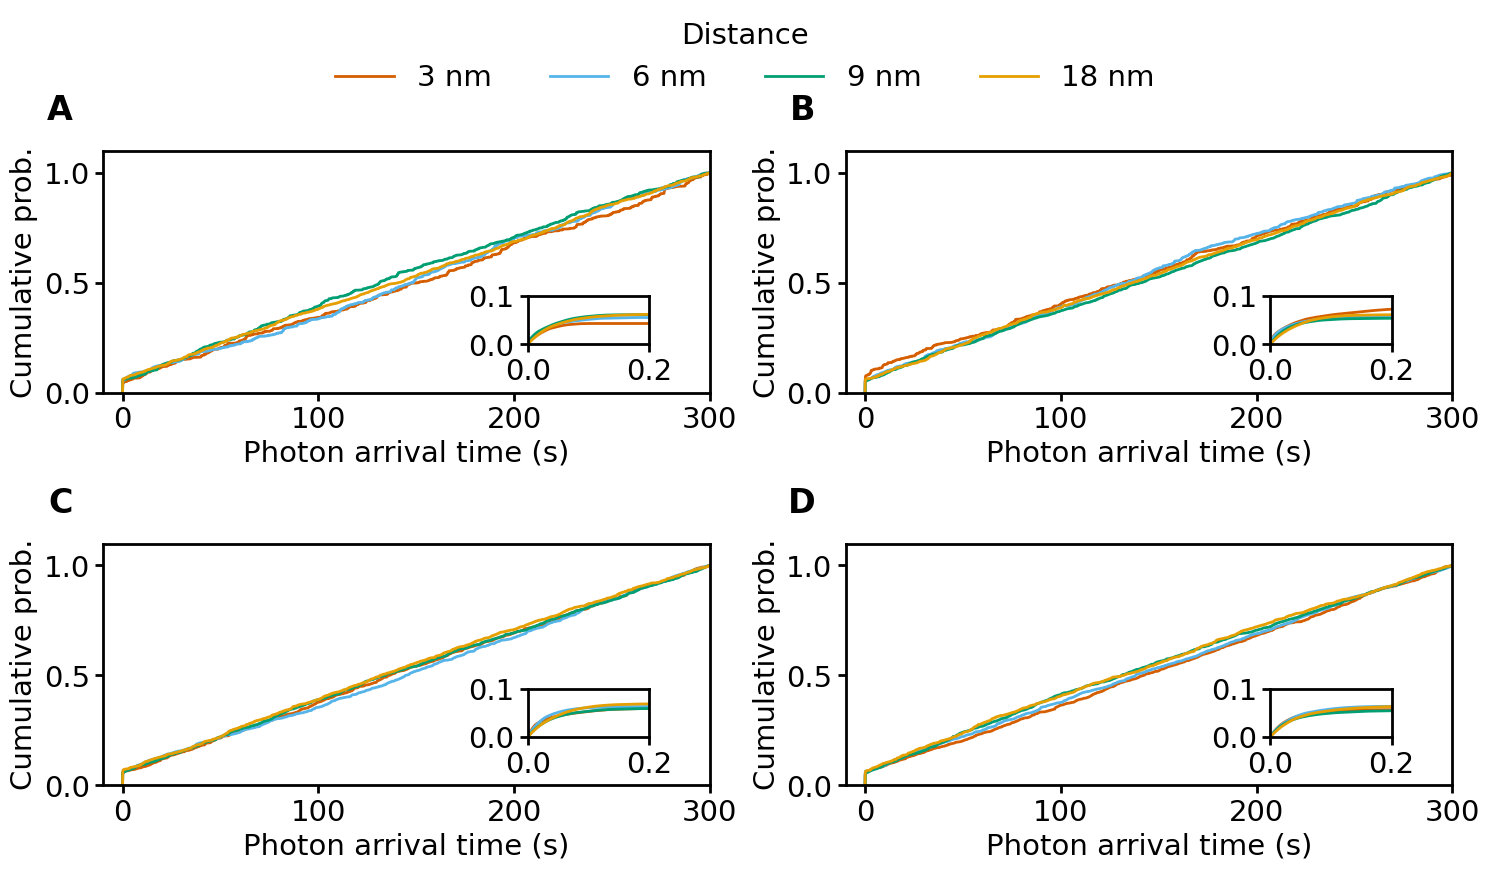

In [6]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]


def plot_figure3(
    ax,
    labels,
    data,
    legendtitle,
    xlim2,
    ylim2,
    spacing2,
    inset_x_ticks,
    colors=colors,
):
    spacing1 = 1
    description = dict(
        ylabel="Cumulative prob.",
        xlabel="Photon arrival time (s)",
        xlim=[-10, 300],
        ylim=[0, 1.1],
    )
    for fingerprint, label, color in zip(data, labels, colors):
        fi.universal_figure(
            data=[fingerprint.index[::spacing1], fingerprint[::spacing1]],
            label=label,
            color=color,
            linestyle="-",
            lw=2,
            axes=ax,
        )
    fi.universal_figure(
        axes=ax,
        **description,
    )

    inset = ax.inset_axes([0.7, 0.2, 0.2, 0.2], xlim=(0, xlim2), ylim=(0, ylim2))
    for fingerprint, label, color in zip(data, labels, colors):
        fi.universal_figure(
            data=[fingerprint.index[::spacing2], fingerprint[::spacing2]],
            axes=inset,
            label=label,
            color=color,
            linestyle="-",
            lw=2,
        )
    inset.set_ylabel("")
    inset.set_xlabel("")
    inset.set_xticks(inset_x_ticks)


rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(2, 4)
fig = plt.figure(figsize=(15, 8))
labels1 = ["3 nm", "6 nm", "9 nm", "18 nm"]
legendtitle1 = "Distance"

ax1 = fig.add_subplot(gs[0, 0:2])
plot_figure3(
    ax1,
    labels1,
    fingerprints_01_all,
    legendtitle1,
    0.2,
    0.1,
    1,
    [0, 0.2],
)

ax2 = fig.add_subplot(gs[0, 2:4])
plot_figure3(
    ax2,
    labels1,
    fingerprints_001_all,
    legendtitle1,
    0.2,
    0.1,
    1,
    [0, 0.2],
)

ax3 = fig.add_subplot(gs[1, 0:2])
plot_figure3(
    ax3,
    labels1,
    fingerprints_0001_all,
    legendtitle1,
    0.2,
    0.1,
    1,
    [0, 0.2],
)

ax4 = fig.add_subplot(gs[1, 2:4])
plot_figure3(
    ax4,
    labels1,
    fingerprints_0_all,
    legendtitle1,
    0.2,
    0.1,
    1,
    [0, 0.2],
)


axes = fig.get_axes()
for axis, letter in zip(axes, ["A", "B", "C", "D"]):
    offset = -0.05
    axis.text(
        offset,
        1.1,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.1),
    frameon=False,
    title="Distance",
    title_fontsize=21,
    fontsize=21,
)

fig.tight_layout()
bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(
    reading_from + r"\multi_f_PFA_higher_exc.png",
    dpi=300,
    bbox_inches=bbox,
)

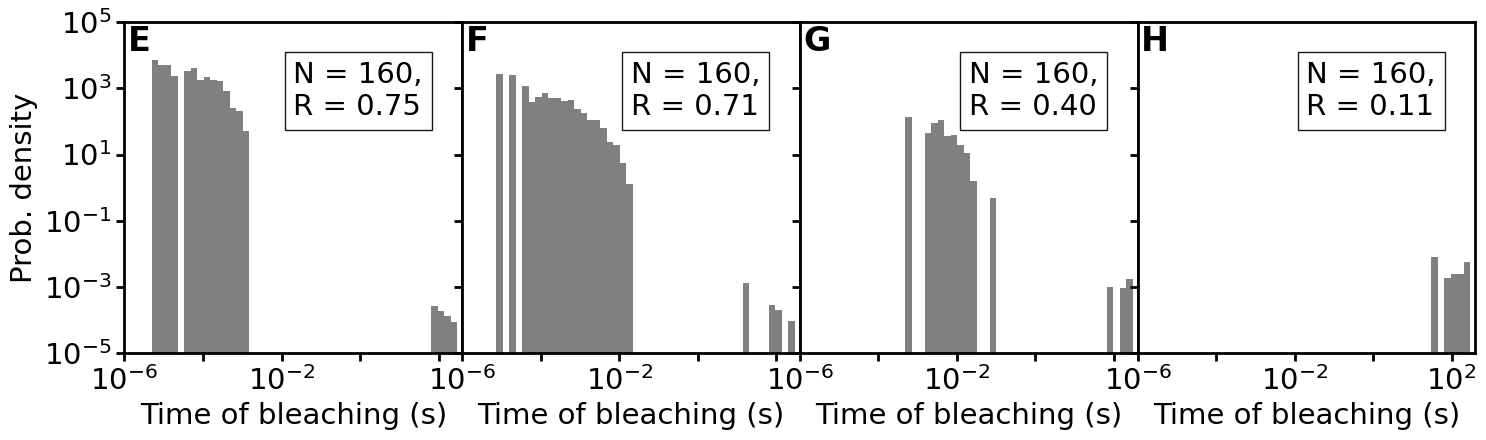

In [8]:
gs = plt.GridSpec(1, 4, wspace=0, hspace=0)
fig = plt.figure(figsize=(15, 4.5))
# only 3 nm
minima = []
for bleaching_times in [
    bleaching_times_01_all,
    bleaching_times_001_all,
    bleaching_times_0001_all,
    bleaching_times_0_all,
]:
    bl_times = bleaching_times[0]
    bl_times = bl_times[:, 0][~np.isnan(bl_times[:, 0])]
    minimum = np.min(bl_times)
    minima.append(minimum)
for i, bleaching_times in enumerate(
    [
        bleaching_times_01_all,
        bleaching_times_001_all,
        bleaching_times_0001_all,
        bleaching_times_0_all,
    ]
):
    bl_times = bleaching_times[0]
    data = bl_times[~np.isnan(bl_times)]
    ratio = data.size / (bl_times.shape[0] * bl_times.shape[1])
    bins = np.logspace(np.log10(np.min(minima)), np.log10(300), 50)
    ax = fig.add_subplot(gs[0, i])

    if i == 3:
        xticklabels = dict(labels=[r"$10^{-6}$", "", r"$10^{-2}$", "", r"$10^{2}$"])
    else:
        xticklabels = dict(labels=[r"$10^{-6}$", "", r"$10^{-2}$", "", ""])

    fi.universal_figure(
        type_="hist",
        data=data,
        bins=bins,
        color="grey",
        axes=ax,
        xlabel="Time of bleaching (s)",
        ylabel="Prob. density",
        xscale="log",
        yscale="log",
        legend=False,
        density=True,
        fontsize=21,
        ylim=[1e-5, 1e5],
        yticks=[1e-5, 1e-3, 1e-1, 1e1, 1e3, 1e5],
        xlim=[1e-6, 4e2],
        xticks=[1e-6, 1e-4, 1e-2, 1e0, 1e2],
        xticklabels=xticklabels,
    )
    props = dict(boxstyle="square", facecolor="white", alpha=0.9, edgecolor="black")
    ax.text(
        0.5,
        0.7,
        f"N = {bl_times.size},\nR = {ratio:.2f}",
        transform=ax.transAxes,
        fontsize=21,
        va="bottom",
        ha="left",
        bbox=props,
    )
letters = ["E", "F", "G", "H"]
for i, axis in enumerate(fig.get_axes()):
    axis.text(
        0.01,
        0.99,
        letters[i],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="top",
        ha="left",
    )
    axis.label_outer()
fig.tight_layout()
bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(
    reading_from + r"\multi_f_PFA_higher_exc_2.png",
    dpi=300,
    bbox_inches=bbox,
)

In [9]:
from PIL import Image

fig1 = Image.open(reading_from + r"\multi_f_PFA_higher_exc.png")
fig2 = Image.open(reading_from + r"\multi_f_PFA_higher_exc_2.png")

combined_height = fig1.height + fig2.height
width = fig1.width

combined = Image.new("RGB", (width, combined_height), (255, 255, 255))
combined.paste(fig1, (0, 0))
combined.paste(fig2, (0, fig1.height))

combined.save(reading_from + r"\merged.png", dpi=(300, 300))